In [8]:
import requests
from oauthlib.oauth2 import BackendApplicationClient
from requests_oauthlib import OAuth2Session
import io
import matplotlib.pyplot as plt
import numpy as np

In [9]:
# Setup Authentication
client_id = 'sh-83b3baad-681c-49ff-967c-a1fe3eed19a4'
client_secret = 'L9cE8ASdvwyY64jWo8nUJQRIZ37A0XpS'
# token
client = BackendApplicationClient(client_id=client_id)
oauth = OAuth2Session(client=client)
token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
token = oauth.fetch_token(token_url=token_url, client_secret=client_secret, include_client_id=True)

In [10]:
url = "https://sh.dataspace.copernicus.eu/api/v1/process"
data = {
  "input": {
    "bounds": {
      "bbox": [150.55, -33.85, 150.75, -33.65]
    },
    "data": [
      {
        "dataFilter": {
          "timeRange": {
            "from": "2019-11-01T00:00:00Z",
            "to": "2019-11-06T23:59:59Z"
          }
        },
        "type": "sentinel-2-l2a"

      }
    ]
  },
  "output": {
    "width": 500,
    "height": 500,
    "responses": [
      {
        "identifier": "default",
        "format": {"type": "image/png"}
      }
    ]
  },
  "evalscript": """
    //VERSION=3
    function setup() {
      return {
        input: ["B08", "B04", "B03"],
        output: { bands: 3 }
      };
    }
    function evaluatePixel(sample) {
      let ndvi = (sample.B08 - sample.B04) / (sample.B08 + sample.B04);
      let ndwi = (sample.B03 - sample.B08) / (sample.B03 + sample.B08);
      return [ndvi, 0, ndwi];
    }
  """
}

#updated token
response = oauth.post(url, json=data)

In [11]:
if response.status_code == 200:
    image = plt.imread(io.BytesIO(response.content))
    fuel_matrix = image[:,:,0]
    water_matrix = image[:,:,2]
    np.save('sentinel_fuel.npy', fuel_matrix)
    np.save('sentinel_water.npy', water_matrix)

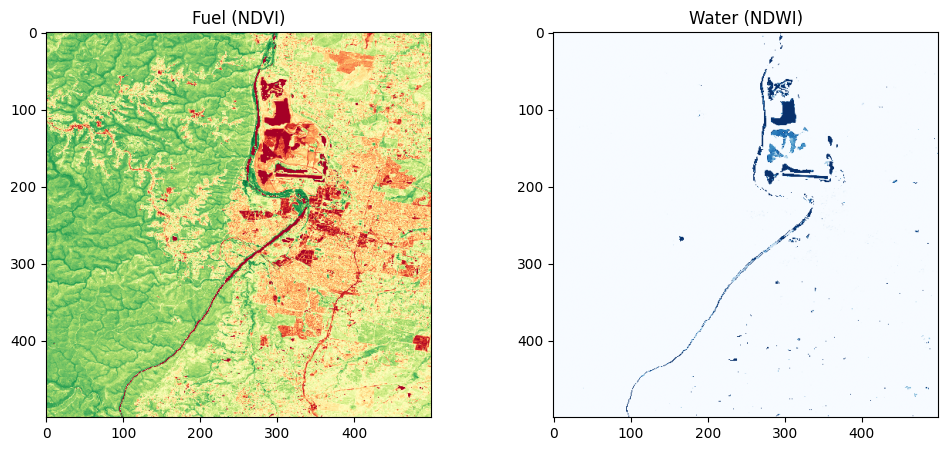

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
ax[0].imshow(fuel_matrix, cmap='RdYlGn')
ax[0].set_title("Fuel (NDVI)")
    
ax[1].imshow(water_matrix, cmap='Blues')
ax[1].set_title("Water (NDWI)")
    
plt.show()